In [82]:
# Source - https://stackoverflow.com/a/9383295
# Posted by David Robinson, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-13, License - CC BY-SA 4.0

import sys
sys.path.append("/Users/emmanuelmakinde/Documents/00_Lab_Deemyad/00_Project_PNNs/")

from pnn_detection_pipeline import PNNPipeline
from ImageTiler import ImageTiler
from pathlib import Path
from PIL import Image
import os
from os import listdir
import numpy as np
import matplotlib.pyplot as plt
# get the path/directory
folder_dir = Path('/Users/emmanuelmakinde/Documents/00_Lab_Deemyad/00_Project_PNNs/00_PV_Segmentation/data/raw/').glob('*tif')

files = {i: file for i, file in enumerate(folder_dir)}
x = np.array(Image.open(files[0]))

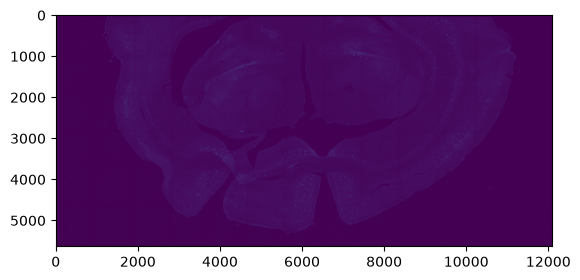

In [51]:
# Let's visualize the image!
plt.plot()
plt.imshow(x)
plt.show()

In [75]:
# Tile Image
tiles = ImageTiler(x, tile_size= 256)
img_tiles = tiles.tiles
print(len(img_tiles))

1056


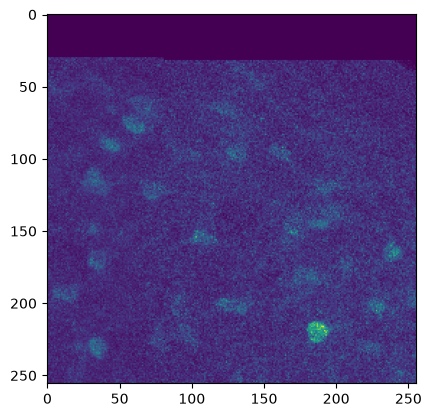

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [111,  95,  49, ..., 153, 105, 188],
       [107, 191,  72, ..., 205, 225, 153],
       [ 45,  99,  66, ..., 293, 104, 156]],
      shape=(256, 256), dtype=uint16)

In [76]:
# Visualize Tiles
img = tiles.tiles[29].image
plt.plot()
plt.imshow(img, cmap='viridis')
plt.show()
img

TypeError: Image data of dtype object cannot be converted to float

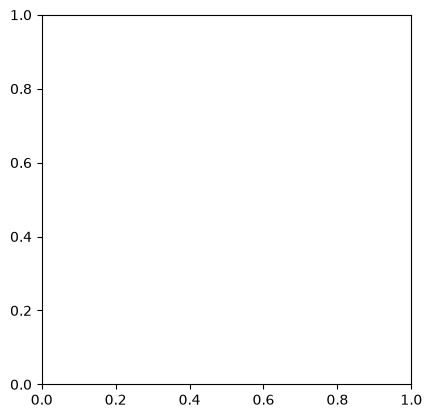

In [ ]:
# Get Candidate on Tiles with Lots of Blobs
img = tiles.tiles[29]
samp_processor = PNNPipeline(difference_of_gaussian= True, hessian= False)
samp_processor.load_image(img)
samp_processor.preprocess()
samp_processor.detect_candidates()
samp_cands = samp_processor.candidates[0].roi

In [78]:
# Get Candidates
from tqdm import tqdm
processor = PNNPipeline(difference_of_gaussian=True, hessian=False)

cands = []

for idx, tile in tqdm(enumerate(img_tiles)):
    processor.load_image(tile)
    processor.preprocess()
    # print(f"processing tile {idx}")
    processor.detect_candidates()
    if len(processor.candidates) > 0:
        processor.extract_rois()
        cands.append(processor.candidates)
    assert idx < 500

500it [00:13, 38.45it/s]


AssertionError: 

In [94]:
# Visualize the candidates
sample_roi = cands[26][10].roi
plt.plot()
plt.imshow(sample_roi, cmap='viridis')
plt.show()

IndexError: list index out of range

In [ ]:
x = img_tiles.tiles[0]